# Maestro MIDI + Loudness Visualizations

This notebook plots the requested three figures for the MAESTRO pair:
1. MIDI notes piano roll.
2. MIDI velocity curve.
3. BSSL total loudness (sones) computed directly from the WAV.


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "src"))

from data_analysis.analysis.visualize_midi_audio import (
    load_pretty_midi,
    extract_note_events,
    build_piano_roll,
    plot_piano_roll,
    plot_velocity_curve,
    compute_bssl_total_loudness,
    plot_bssl_total_loudness,
    compute_velocity_curve_from_midi,
    compare_velocity_with_bssl,
    compare_midi_velocity_files,
    compare_bssl_audio_files,
)

midi_path = Path("/media/datadisk/home/22828187/zhanh/Dataset/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi")
wav_path = Path("/media/datadisk/home/22828187/zhanh/Dataset/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.wav")
fig_dir = Path("figures/maestro_track05")
fig_dir.mkdir(parents=True, exist_ok=True)
print("Figures will be saved to", fig_dir.resolve())

midi_path_ref = midi_path
wav_path_ref = wav_path
midi_path_b = Path("/media/datadisk/home/22828187/zhanh/Dataset/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi")
wav_path_b = Path("/media/datadisk/home/22828187/zhanh/Dataset/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.wav")


Figures will be saved to /media/datadisk/home/22828187/zhanh/202601_midisemi/data_analysis/figures/maestro_track05


Loaded MIDI with 7894 notes and piano roll shape (128, 48451).
Processed WAV at 22050 Hz; loudness shape = (48481,).


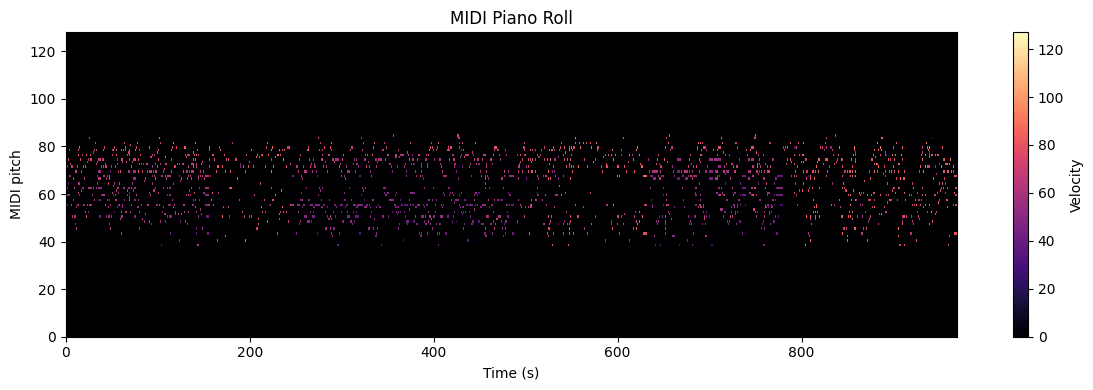

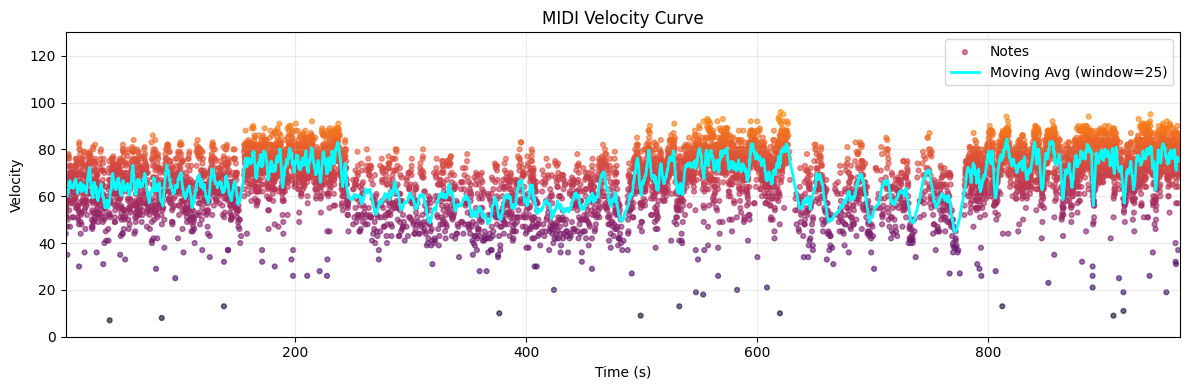

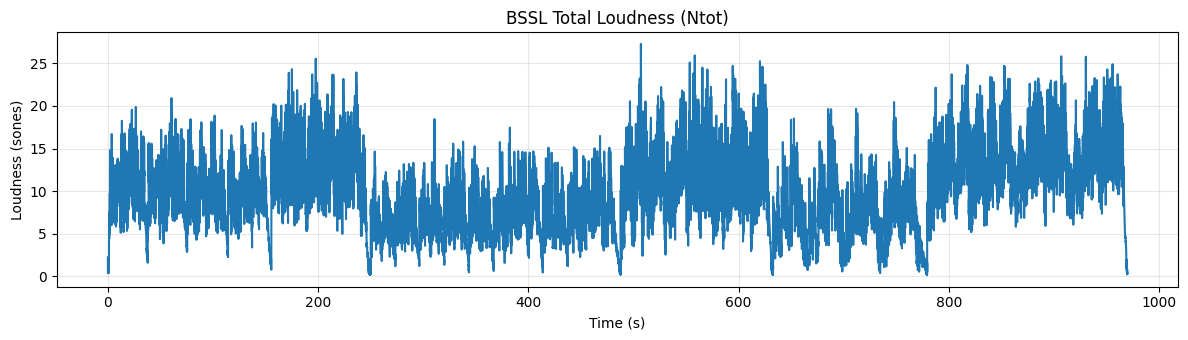

In [ ]:
pm = load_pretty_midi(midi_path)
note_times, velocities, pitches = extract_note_events(pm)
piano_times, piano_roll = build_piano_roll(pm, fs=50)
print(f"Loaded MIDI with {len(velocities)} notes and piano roll shape {piano_roll.shape}.")

piano_roll_fig = plot_piano_roll(
    piano_times,
    piano_roll,
    output_path=fig_dir / "piano_roll.png",
)
velocity_fig = plot_velocity_curve(
    note_times,
    velocities,
    window=25,
    output_path=fig_dir / "velocity_curve.png",
)

loudness_times, loudness, sample_rate = compute_bssl_total_loudness(
    wav_path,
    target_sample_rate=22050,
    frames_per_second=50,
    fft_size=1024,
)
print(f"Processed WAV at {sample_rate} Hz; loudness shape = {loudness.shape}.")
loudness_fig = plot_bssl_total_loudness(
    loudness_times,
    loudness,
    output_path=fig_dir / "bssl_total_loudness.png",
)
# piano_roll_fig


In [36]:
velocity_bssl_stats = compare_velocity_with_bssl(
    midi_path,
    wav_path,
    target_sample_rate=22050,
    frames_per_second=50,
    fft_size=1024,
    velocity_smoothing=25,
    micro_window_seconds=30.0,
)
velocity_bssl_stats["metrics"]

{'cosine_similarity': 0.7434477488502835,
 'pearson_correlation': 0.7434477488502836,
 'spearman_correlation': 0.7884881931339401,
 'mean_absolute_error': 0.5278954765462213,
 'mean_squared_error': 0.5131045022994333}

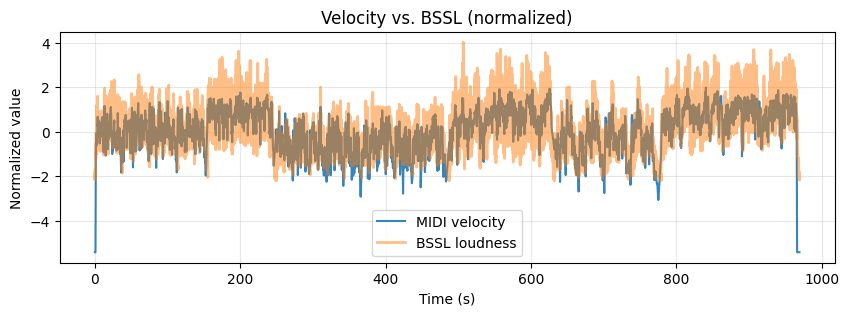

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(velocity_bssl_stats["times"], velocity_bssl_stats["velocity_normalized"], label="MIDI velocity", alpha=0.9, linewidth=1.5)
ax.plot(velocity_bssl_stats["times"], velocity_bssl_stats["loudness_normalized"], label="BSSL loudness", alpha=0.5, linewidth=2.0)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized value")
ax.set_title("Velocity vs. BSSL (normalized)")
ax.grid(True, alpha=0.3)
ax.legend()

# Actually Apply

In [2]:
# Renew Path of actual application
midi_path = Path("/media/datadisk/home/22828187/zhanh/Dataset/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi")
midi_path_b = Path("/media/datadisk/home/22828187/zhanh/202601_midisemi_data/kim_ismir2024/output/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav_vel.mid")

velocity_cross_stats = compare_midi_velocity_files(
    midi_path,
    midi_path_b,
    frames_per_second=50,
    smoothing_window=5,
    num_samples=2048,
    micro_window_seconds=30.0,
)
velocity_cross_stats["metrics"]

{'cosine_similarity': -0.08808238458449073,
 'pearson_correlation': -0.0880823845844907,
 'spearman_correlation': -0.11738032965089656,
 'mean_absolute_error': 1.1813744528977537,
 'mean_squared_error': 2.176164769168982}

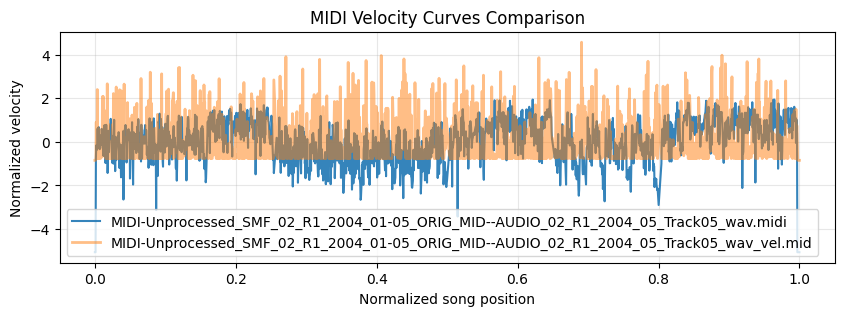

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(velocity_cross_stats["grid"], velocity_cross_stats["normalized_a"], label=midi_path.name, alpha=0.9, linewidth=1.5)
ax.plot(velocity_cross_stats["grid"], velocity_cross_stats["normalized_b"], label=midi_path_b.name, alpha=0.5, linewidth=2.0)
ax.set_xlabel("Normalized song position")
ax.set_ylabel("Normalized velocity")
ax.set_title("MIDI Velocity Curves Comparison")
ax.grid(True, alpha=0.3)
ax.legend()

Loaded MIDI with 7894 notes and piano roll shape (128, 48451).


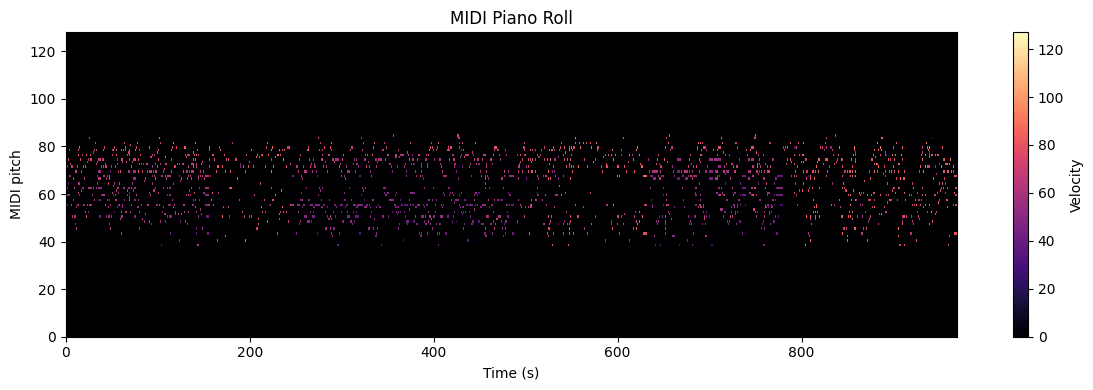

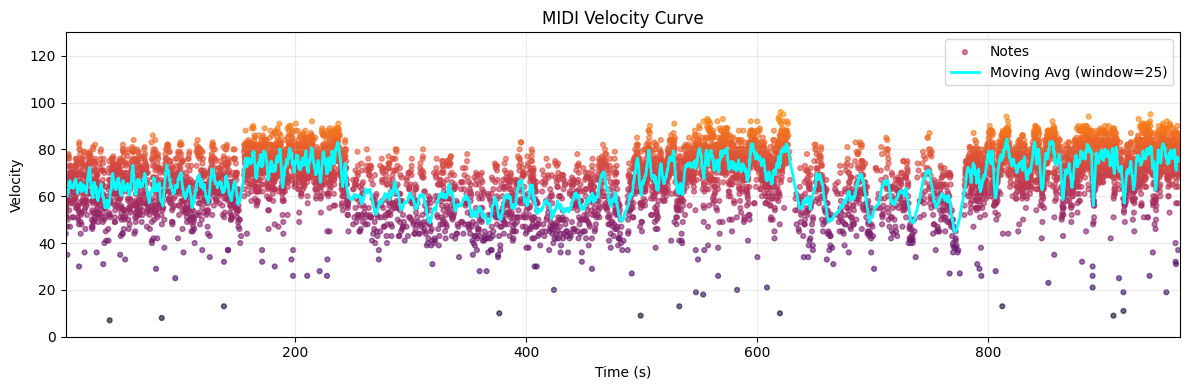

In [4]:
pm = load_pretty_midi(midi_path)
note_times, velocities, pitches = extract_note_events(pm)
piano_times, piano_roll = build_piano_roll(pm, fs=50)
print(f"Loaded MIDI with {len(velocities)} notes and piano roll shape {piano_roll.shape}.")

piano_roll_fig = plot_piano_roll(
    piano_times,
    piano_roll,
    output_path=fig_dir / "piano_roll.png",
)
velocity_fig = plot_velocity_curve(
    note_times,
    velocities,
    window=25,
    output_path=fig_dir / "velocity_curve.png",
)

Loaded MIDI with 7894 notes and piano roll shape (128, 48430).


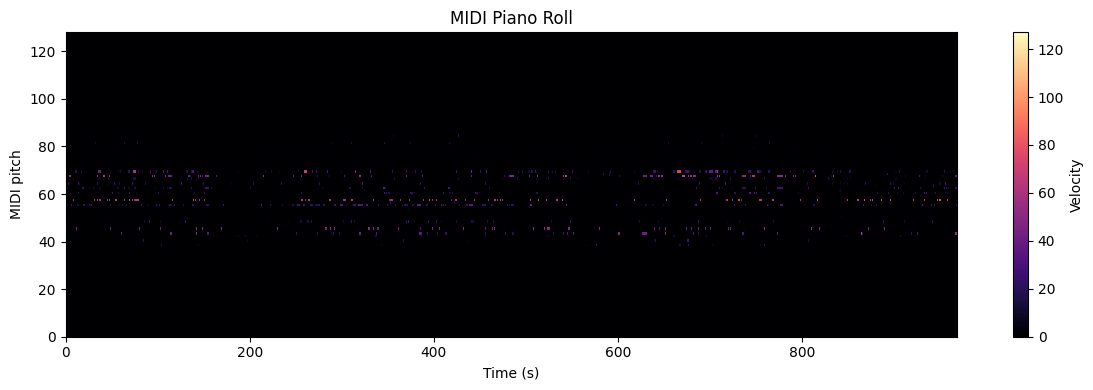

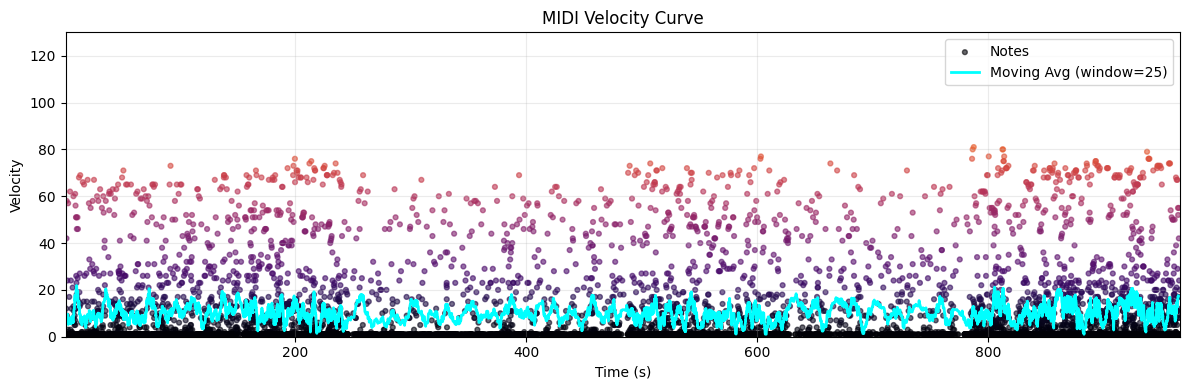

In [5]:
pm = load_pretty_midi(midi_path_b)
note_times, velocities, pitches = extract_note_events(pm)
piano_times, piano_roll = build_piano_roll(pm, fs=50)
print(f"Loaded MIDI with {len(velocities)} notes and piano roll shape {piano_roll.shape}.")

piano_roll_fig = plot_piano_roll(
    piano_times,
    piano_roll,
    output_path=fig_dir / "piano_roll.png",
)
velocity_fig = plot_velocity_curve(
    note_times,
    velocities,
    window=25,
    output_path=fig_dir / "velocity_curve.png",
)

In [34]:
velocity_cross_stats = compare_midi_velocity_files(
    midi_path,
    midi_path_b,
    frames_per_second=50,
    smoothing_window=5,
    num_samples=2048,
    micro_window_seconds=30.0,
)
velocity_cross_stats["metrics"]

{'cosine_similarity': -0.023827657004853377,
 'pearson_correlation': -0.023827657004853356,
 'spearman_correlation': -0.08273323688453035,
 'mean_absolute_error': 1.1412500730013393,
 'mean_squared_error': 2.047655314009707}

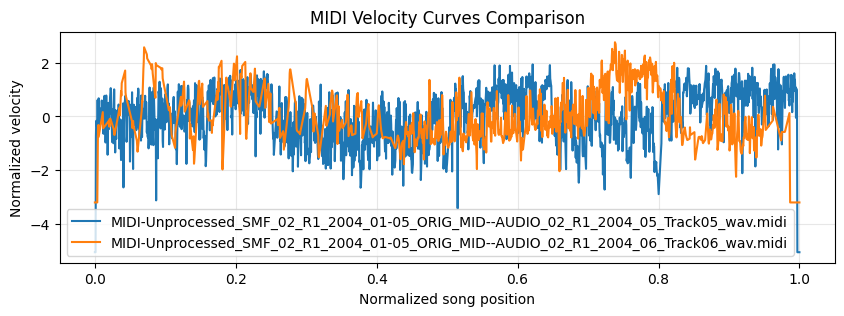

In [35]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(velocity_cross_stats["grid"], velocity_cross_stats["normalized_a"], label=midi_path.name)
ax.plot(velocity_cross_stats["grid"], velocity_cross_stats["normalized_b"], label=midi_path_b.name)
ax.set_xlabel("Normalized song position")
ax.set_ylabel("Normalized velocity")
ax.set_title("MIDI Velocity Curves Comparison")
ax.grid(True, alpha=0.3)
ax.legend()

In [ ]:
bssl_cross_stats = compare_bssl_audio_files(
    wav_path,
    wav_path_b,
    target_sample_rate=22050,
    frames_per_second=50,
    fft_size=1024,
    num_samples=2048,
)
bssl_cross_stats["metrics"]

{'cosine_similarity': -0.0904202795028797,
 'pearson_correlation': -0.09042027950287969,
 'spearman_correlation': -0.08201448060172332,
 'mean_absolute_error': 1.1525115631927967,
 'mean_squared_error': 2.180840559005759}

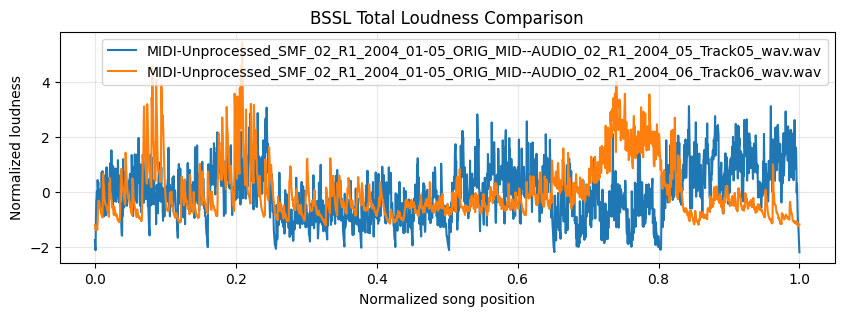

In [37]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(bssl_cross_stats["grid"], bssl_cross_stats["normalized_a"], label=wav_path.name)
ax.plot(bssl_cross_stats["grid"], bssl_cross_stats["normalized_b"], label=wav_path_b.name)
ax.set_xlabel("Normalized song position")
ax.set_ylabel("Normalized loudness")
ax.set_title("BSSL Total Loudness Comparison")
ax.grid(True, alpha=0.3)
ax.legend()